In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "configs").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import yaml
import pandas as pd
import numpy as np

import data.load_data as load_data

from matplotlib import pyplot as plt
import importlib
import notebooks.plottingtool as plottingtool
importlib.reload(plottingtool)
from notebooks.plottingtool import plot_1d_hist, plot_2d_hist, plot_2d_res_hist

import mplhep as hep
hep.style.use("ATLAS")


In [2]:
data = load_data.load_particles_from_h5("/root/data/danning_h5/ypeng/mc20_qe_v4_recotruth_merged.h5").get("ggF_train")
# print(data.keys())
true_nu = data["truth_nu"]
true_anti_nu = data["truth_antinu"]
true_nu_px = true_nu["px"]
true_nu_py = true_nu["py"]
true_anti_nu_px = true_anti_nu["px"]
true_anti_nu_py = true_anti_nu["py"]
true_nunu_px = true_nu_px + true_anti_nu_px
true_nunu_py = true_nu_py + true_anti_nu_py
true_nunu_pt = np.sqrt(true_nunu_px**2 + true_nunu_py**2)

reco_met = data["met"]
reco_met_pt = reco_met["pt"]
reco_met_phi = reco_met["phi"]
reco_met_px = reco_met["px"]
reco_met_py = reco_met["py"]

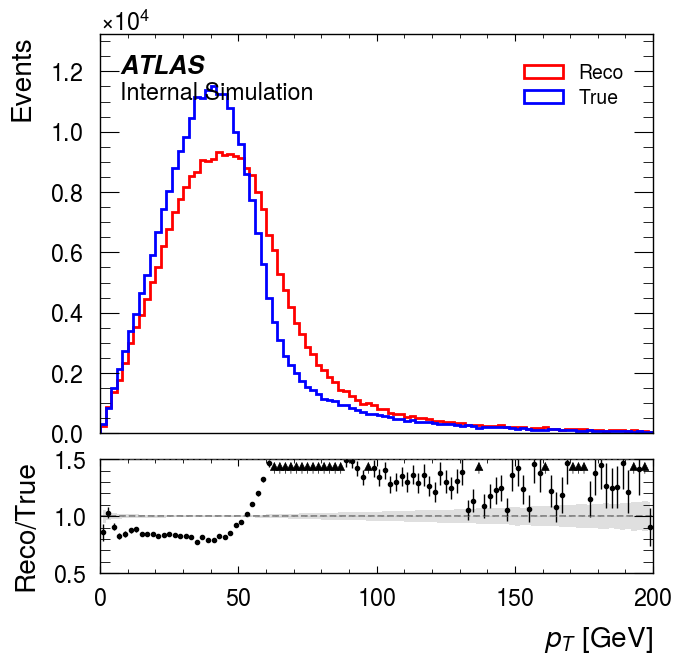

Rel err < 20%: 38.66 %


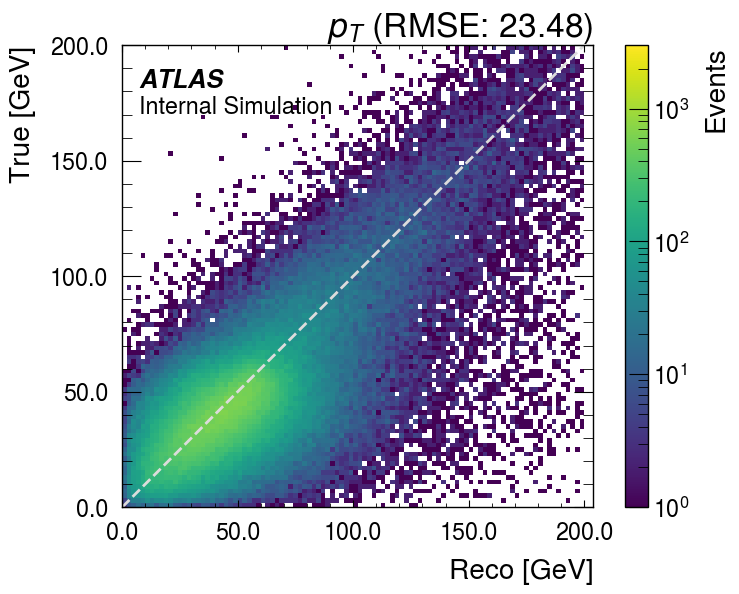

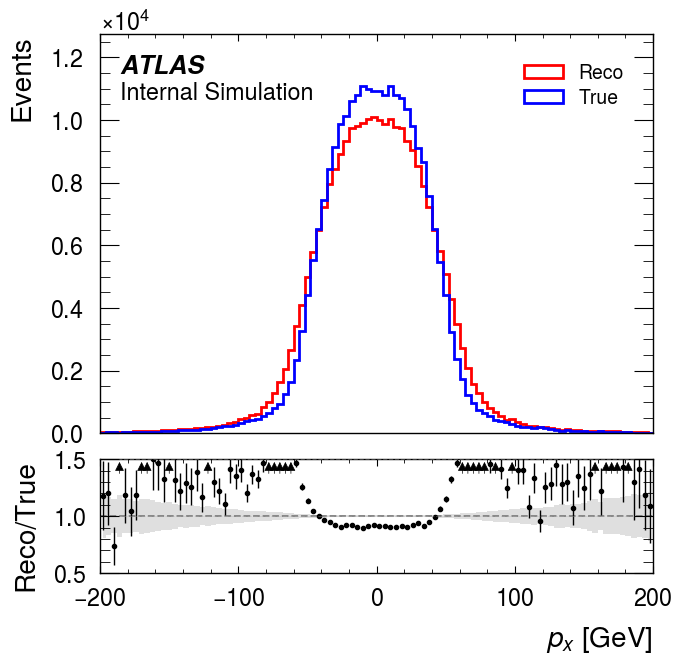

Rel err < 20%: 24.94 %


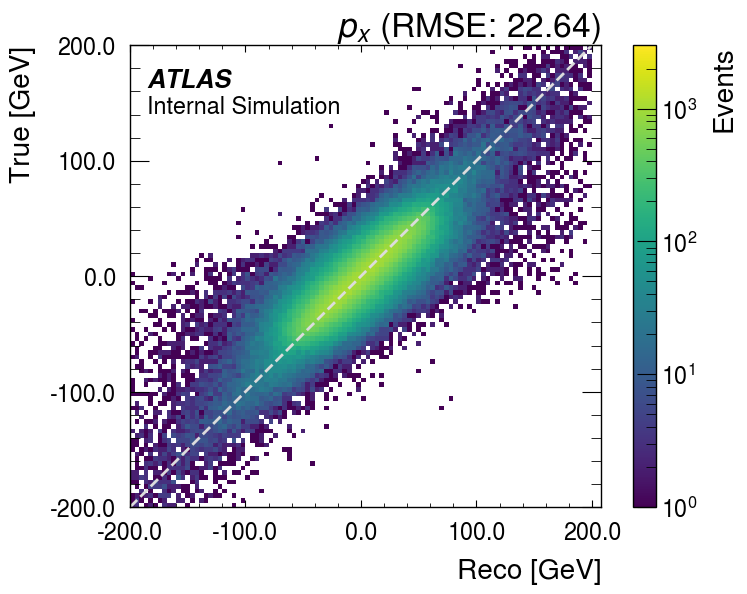

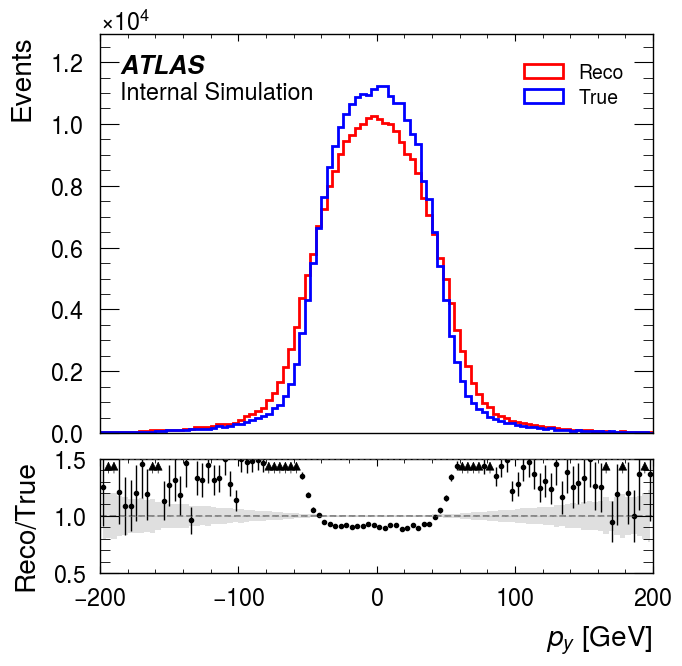

Rel err < 20%: 24.84 %


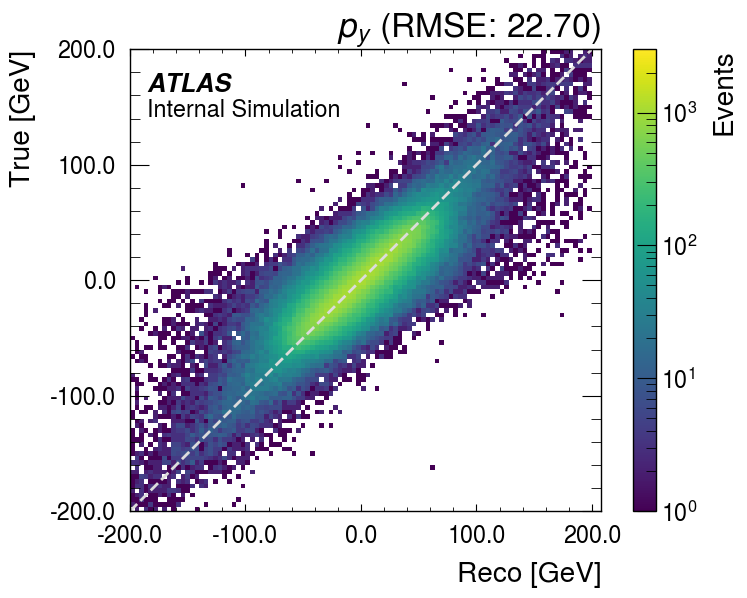

In [4]:
plot_1d_hist(reco_met_pt, true_nunu_pt, r"$p_T$", ratio_text="Reco/True", bins_edges=np.linspace(0, 200, 101))
plot_2d_hist(reco_met_pt, true_nunu_pt, r"$p_T$", xlabel="Reco", ylabel="True", bins_edges=np.linspace(0, 200, 101), log=True, vmax=3000)
plot_1d_hist(reco_met_px, true_nunu_px, r"$p_x$", ratio_text="Reco/True", bins_edges=np.linspace(-200, 200, 101))
plot_2d_hist(reco_met_px, true_nunu_px, r"$p_x$", xlabel="Reco", ylabel="True", bins_edges=np.linspace(-200, 200, 101), log=True, vmax=3000)
plot_1d_hist(reco_met_py, true_nunu_py, r"$p_y$", ratio_text="Reco/True", bins_edges=np.linspace(-200, 200, 101))
plot_2d_hist(reco_met_py, true_nunu_py, r"$p_y$", xlabel="Reco", ylabel="True", bins_edges=np.linspace(-200, 200, 101), log=True, vmax=3000)